In [22]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import os

# Local packages
from etc.hamiltonian import Hamiltonian
from etc_utils.graph_models import *
from etc_utils.phase_diagrams import *

In [23]:
Gs = get_graphs_list()

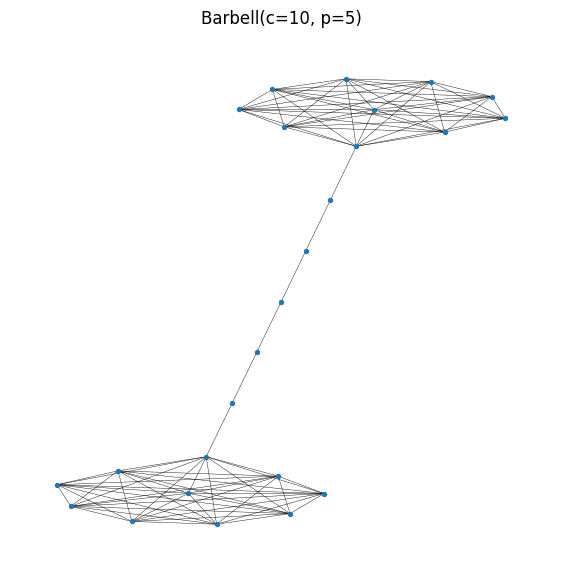

In [24]:
show_graph(Gs[0][1], title=Gs[0][0])

In [25]:
H1 = Hamiltonian(Gs[0][1])
# parameter mu predefined
mu=H1.mu_density_aware(G=Gs[0][1])
# parameter gamma predefined
gamma=H1.gamma_balancer(mu=mu)
# Adjacency matrix upper triangle
A = np.triu(nx.to_numpy_array(Gs[0][1]))
# Inverse of distance matrix upper triangle
D2 = H1.Dinv2_triu
indices = H1.nodes

In [26]:
k = 5
Hmin,min_nodes = sample_k_closest_to_zero(H=H1, k=k, mu=mu, gamma=gamma, A=A, D2=D2)

In [27]:
Hmaxneg,max_nodesneg = solve_extreme_k(A,D=H1.distance_matrix, k=k, mu=mu, gamma=gamma,sense='min')

In [28]:
Hmaxpos,max_nodespos = solve_extreme_k(A,D=H1.distance_matrix, k=k, mu=mu, gamma=gamma,sense='max')

In [29]:
max_nodesneg

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1])

In [30]:
max_nodespos

array([1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1])

In [31]:
min_nodes

[16, 15, 13, 5, 12]

In [32]:
# Prepare output directory
out_dir = "figures"
os.makedirs(out_dir, exist_ok=True)

In [33]:
# Publication-style rcParams (local update)
old_rc = plt.rcParams.copy()
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
})

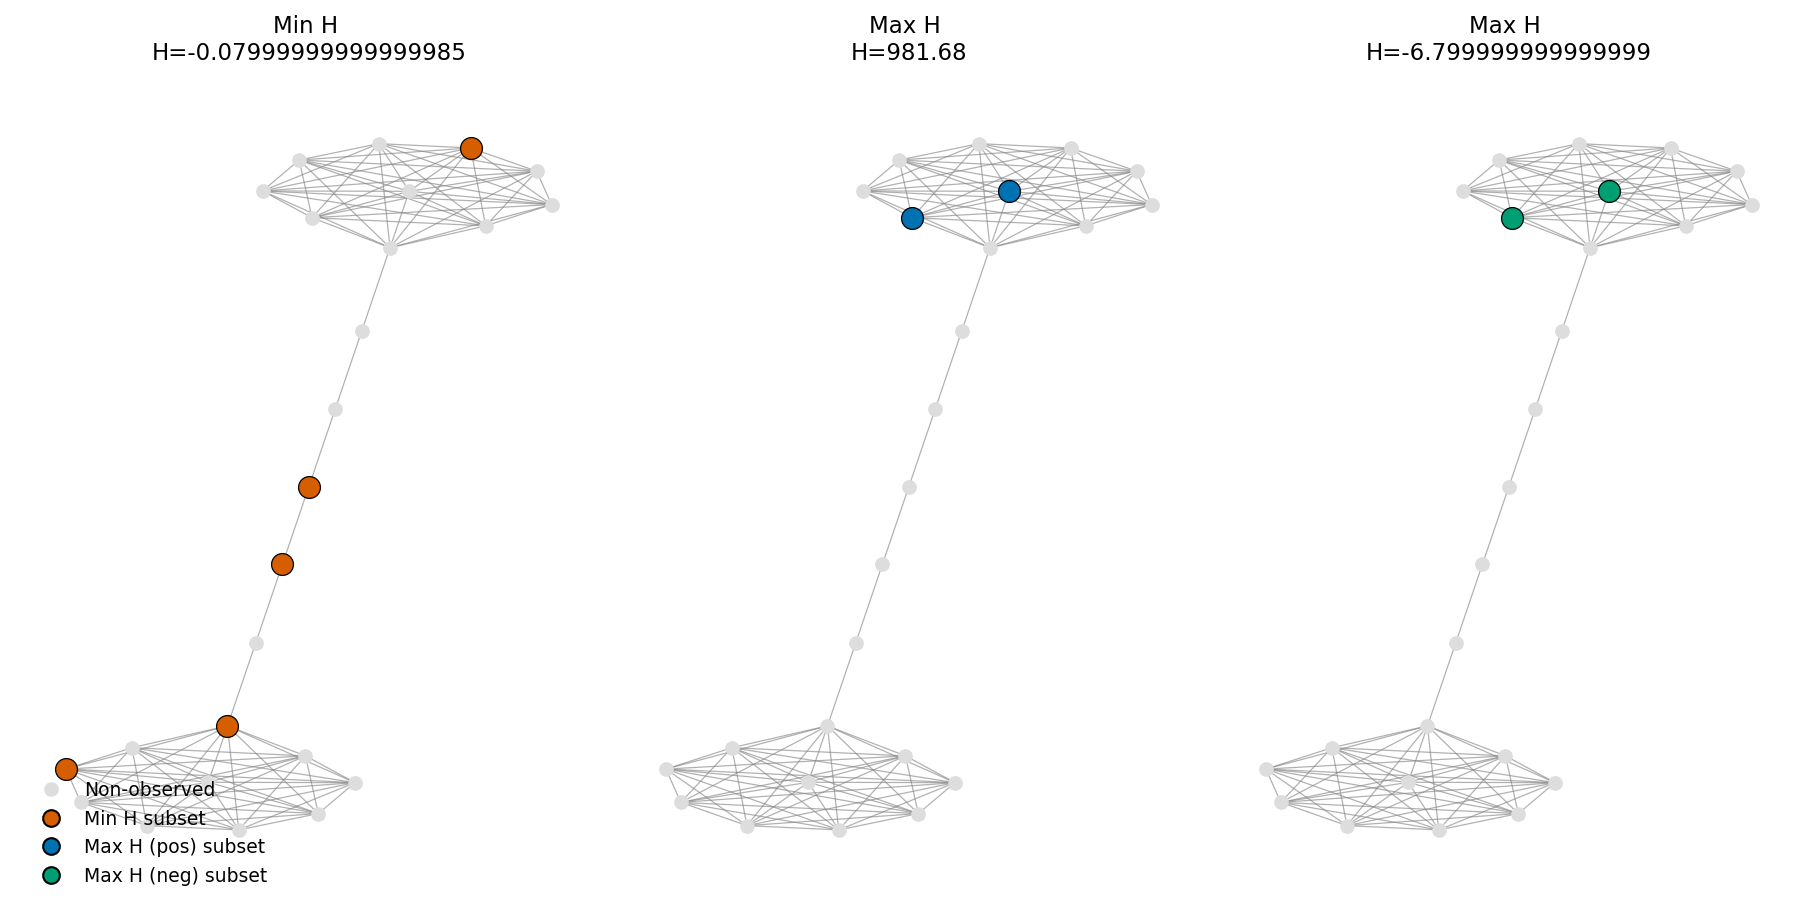

In [34]:

# layout
pos = smart_layout(Gs[0][1])

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(12, 6), constrained_layout=True)
titles = [
    f"Min H \nH={Hmin if Hmin is not None else 'n/a'}",
    f"Max H \nH={Hmaxpos if Hmaxpos is not None else 'n/a'}",
    f"Max H \nH={Hmaxneg if Hmaxneg is not None else 'n/a'}",
]
# Colorblind-friendly palette
colors = ['#D55E00', '#0072B2', '#009E73'] 
bg_color = '#DDDDDD'
edge_color = '#888888'
node_size_bg = 50              # increased background node size for visibility
node_size_highlight = 110     # reduced highlight size to avoid overpowering the layout
edge_alpha = 0.65             # stronger edges for context
edge_width = 0.6

for ax, subset_set, title, color in zip(axes, [min_nodes, max_nodespos, max_nodesneg], titles, colors):
    ax.set_title(title, pad=6)
    ax.axis('off')

    # draw edges first (now less transparent to show structure)
    nx.draw_networkx_edges(
        Gs[0][1], pos, ax=ax, width=edge_width, alpha=edge_alpha, edge_color=edge_color)

    # draw background nodes (muted but slightly larger)
    background = [n for n in Gs[0][1].nodes() if n not in subset_set]
    nx.draw_networkx_nodes(
        Gs[0][1], pos, nodelist=background, node_color=bg_color, 
        node_size=node_size_bg, linewidths=0, ax=ax)

    # draw highlighted nodes with black outlines for clarity (smaller than before)
    highlight_nodes = [n for n in Gs[0][1].nodes() if n in subset_set]
    nx.draw_networkx_nodes(
        Gs[0][1], pos, nodelist=highlight_nodes, node_color=color, 
        node_size=node_size_highlight, edgecolors='black', linewidths=0.6, ax=ax)

# Add a minimal legend on the left axis
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=bg_color, markersize=6, label='Non-observed', markeredgecolor=bg_color),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[0], markeredgecolor='k', markersize=8, label='Min H subset'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[1], markeredgecolor='k', markersize=8, label='Max H (pos) subset'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[2], markeredgecolor='k', markersize=8, label='Max H (neg) subset'),
]
axes[0].legend(handles=handles, loc='lower left', frameon=False)

# # Save high-quality PNG and also PDF for paper use
# out_path_png = os.path.join(out_dir, f"min_max_subsets_{imin}_{imax}.png")
# out_path_pdf = os.path.join(out_dir, f"min_max_subsets_{imin}_{imax}.pdf")
# fig.savefig(out_path_png, dpi=300, bbox_inches='tight')
# try:
#     fig.savefig(out_path_pdf, dpi=300, bbox_inches='tight')
# except Exception:
#     # PDF writer might not be available — ignore silently
#     pass

plt.show()

# restore rcParams to avoid side effects on other cells
plt.rcParams.update(old_rc)